# Modelos sin tratamiento de datos inicial

Importación de las librerías que se van a usar en el cuaderno

In [2]:
import matplotlib.pyplot as plt # se usa para graficar
import numpy as np # álgebra lineal
import pandas as pd # procesamiento de datos, entrada/salida de archivos CSV (por ejemplo, pd.read_csv)
import seaborn as sns # se usa para graficar de manera interactiva
from IPython.display import Image # para mostrar imágenes
from io import StringIO # para trabajar con flujos de datos
from matplotlib.colors import ListedColormap # se usa para graficar con colores personalizados
from sklearn.metrics import classification_report # para el reporte de clasificación
from sklearn.metrics import confusion_matrix # se usa para calcular la matriz de confusión
from sklearn.model_selection import train_test_split # para dividir los datos en dos partes
from sklearn.naive_bayes import GaussianNB # para el algoritmo de Naive Bayes
from sklearn.neighbors import KNeighborsClassifier # para el algoritmo de K vecinos más cercanos
from sklearn.preprocessing import LabelEncoder # para codificar etiquetas
from sklearn.tree import DecisionTreeClassifier # para usar el algoritmo de árbol de decisión
from sklearn.tree import export_graphviz # para exportar datos en formato dot
 
plt.rcParams['figure.figsize'] = (16, 9) # se usa para establecer el tamaño de la gráfica
plt.style.use('ggplot') # se usa para establecer el estilo de la gráfica

Se cargan los datos del fichero CSV

In [3]:
dataframe = pd.read_csv(r"homeLoanAproval.csv",sep=',')
dataframe.head(10)

,Loan_ID,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,PropertyArea,LoanStatus
0,LP001002,Male,No,0,Graduate,No,5849,0,NaN,360.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267.0,360.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516,95.0,360.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504,158.0,360.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526,168.0,360.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968,349.0,360.0,Semiurban,N


In [ ]:
# Borramos las filas incompletas
dataframe.dropna(how="any", inplace=True)
# Borramos las filas que tienen algún dato '3+' (No lo podemos usar)
dataframe = dataframe[dataframe.Dependents != '3+']
dataframe = dataframe[dataframe.CoapplicantIncome.str.contains('^[0-9]+.[0-9]+$')]
dataframe['Dependents'] = dataframe['Dependents'].apply(pd.to_numeric)

In [6]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 1 to 611
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            268 non-null    object 
 1   Gender             268 non-null    object 
 2   Married            268 non-null    object 
 3   Dependents         268 non-null    int64  
 4   Education          268 non-null    object 
 5   SelfEmployed       268 non-null    object 
 6   ApplicantIncome    268 non-null    int64  
 7   CoapplicantIncome  268 non-null    object 
 8   LoanAmount         268 non-null    float64
 9   LoanAmountTerm     268 non-null    float64
 10  PropertyArea       268 non-null    object 
 11  LoanStatus         268 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 27.2+ KB


Quitamos las columnas de variables no numéricas y variables que no aportan información útil

In [7]:
dataframe = dataframe.drop('Gender', axis=1)
dataframe = dataframe.drop('Married', axis=1)
dataframe = dataframe.drop('Education', axis=1)
dataframe = dataframe.drop('SelfEmployed', axis=1)
dataframe = dataframe.drop('PropertyArea', axis=1)
dataframe = dataframe.drop('Loan_ID', axis=1)

In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 1 to 611
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dependents         268 non-null    int64  
 1   ApplicantIncome    268 non-null    int64  
 2   CoapplicantIncome  268 non-null    object 
 3   LoanAmount         268 non-null    float64
 4   LoanAmountTerm     268 non-null    float64
 5   LoanStatus         268 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 14.7+ KB


Tras preparar el dataframe, se crean grupo de entrenamiento y testeo aleatoriamente

In [9]:
x = dataframe.drop('LoanStatus', axis=1)
y = dataframe['LoanStatus'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

## K-vecinos

Primero se establece un número de vecinos aleatorio y posteriormente se modifica para mejorar los resultados

In [21]:
n_neighbors = 9
knn = KNeighborsClassifier(n_neighbors)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [22]:
print('Accuracy of K-NN classifier on training set: {:.2f}'.format(knn.score(x_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'.format(knn.score(x_test, y_test)))

Accuracy of K-NN classifier on training set: 0.75
Accuracy of K-NN classifier on test set: 0.67


Teniendo los resultados, veamos la matriz de confusión

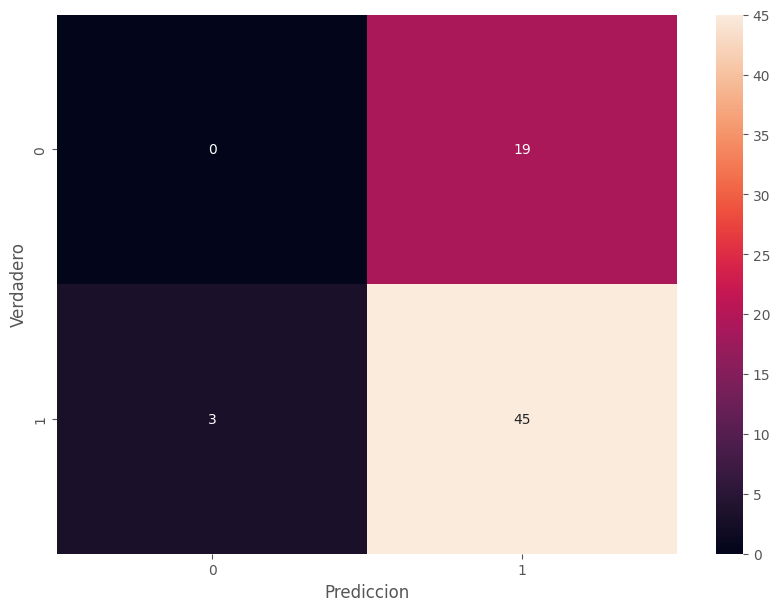

In [ ]:
# Se crea una matriz de confusión
predccion = knn.predict(x_test)
matriz = confusion_matrix(y_test, predccion)

# Se imprime la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(matriz, annot=True, fmt='d')
plt.xlabel('Prediccion')
plt.ylabel('Verdadero')

plt.show()

Con esta matriz podemos ver que el clasificador no está funcionando de manera correcta, ya que se puede ver que cuando debería marcar como no conceder crédito a 19 personas, marcó en todos los casos que sí. Comparando este resutlado con el caso de sí conceder crédito, parece que el modelo marca "sí" para casi todos los casos.

## Árbol de clasificación

Ahora creamos un árbol de clasificación creando los respectivos grupos de entrenamiento y de testeo.

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [ ]:
# Se crea y entrena el modelo de árbol de decisión
clf = DecisionTreeClassifier()
clf = clf.fit(x_train, y_train)

# Se realizan predicciones con el modelo entrenado
y_pred = clf.predict(x_test)

In [27]:
print('Accuracy of classifier on training set: {:.2f}'.format(clf.score(x_train, y_train)))
print('Accuracy of classifier on test set: {:.2f}'.format(clf.score(x_test, y_test)))

Accuracy of classifier on training set: 1.00
Accuracy of classifier on test set: 0.54


Como se puede apreciar, el árbol de clasificación se ciñe completamente a los datos del entrenamiento.

Imprimimos la matriz de confusión para ver los resultados.

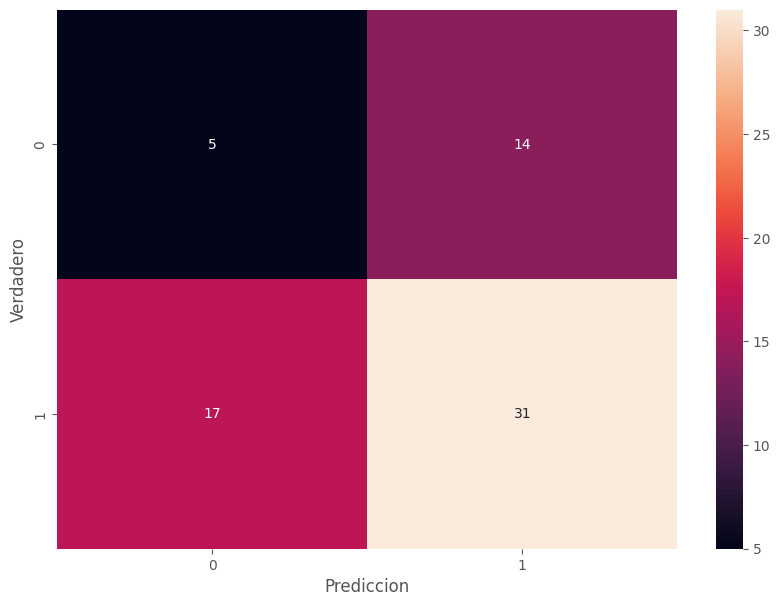

In [29]:
# Se crea una matriz de confusión
predccion = clf.predict(x_test)
matriz = confusion_matrix(y_test, predccion)

# Se imprime la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(matriz, annot=True, fmt='d')
plt.xlabel('Prediccion')
plt.ylabel('Verdadero')

plt.show()

Aunque ahora no marca todo que sí, la presición a bajado casi un 15%, por lo que seguimos teniendo una mala predicción en el modelo.

In [40]:
dataframe.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,LoanStatus
1,1,4583,1508,128.0,360.0,N
3,0,2583,2358,120.0,360.0,Y
5,2,5417,4196,267.0,360.0,Y
6,0,2333,1516,95.0,360.0,Y
8,2,4006,1526,168.0,360.0,Y


## Naive Bayes

Volvemos a crear los conjuntos de entrenamiento y de testeo para la validación.

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10)

In [ ]:
# Se creal el modelo
naive_bayes = GaussianNB()
naive_bayes = naive_bayes.fit(x_train, y_train)
y_pred = naive_bayes.predict(x_test)

In [48]:
print('Accuracy of classifier on training set: {:.2f}'.format(naive_bayes.score(x_train, y_train)))
print('Accuracy of classifier on test set: {:.2f}'.format(naive_bayes.score(x_test, y_test)))

Accuracy of classifier on training set: 0.71
Accuracy of classifier on test set: 0.70


Aparentemente hay una mejora con respecto a los anteriores modelos.

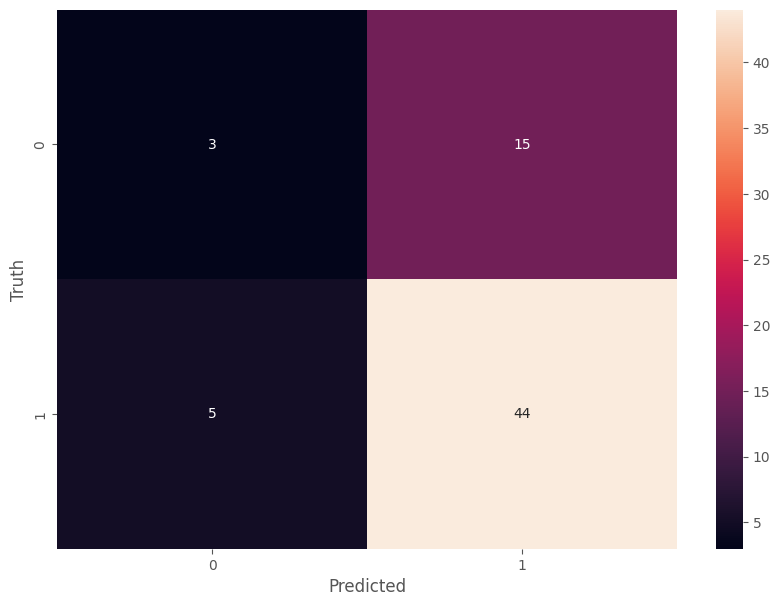

In [50]:
prediccion = naive_bayes.predict(x_test)
matriz = confusion_matrix(y_test, prediccion)

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(matriz, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.show()

Pero se tiene el mismo problema que en el caso de k-vecinos.

# Modelos con tratamiento de datos inicial.

In [ ]:
dataframe = pd.read_csv(r"homeLoanAproval.csv",sep=',')

# Cambiamos los '3+' por '3'
dataframe['Dependents'] = dataframe['Dependents'].replace('3+', 3)
dataframe['Dependents'] = dataframe['Dependents'].apply(pd.to_numeric)

# Arreglamos los números con puntos
dataframe['CoapplicantIncome'] = dataframe['CoapplicantIncome'].replace('\\.', '', regex=True)
dataframe['CoapplicantIncome'] = dataframe['CoapplicantIncome'].apply(pd.to_numeric)

dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    float64
 4   Education          614 non-null    object 
 5   SelfEmployed       582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         592 non-null    float64
 9   LoanAmountTerm     600 non-null    float64
 10  PropertyArea       614 non-null    object 
 11  LoanStatus         614 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 57.7+ KB


Quitamos las columnas que no se van a utilizar.

In [53]:
dataframe = dataframe.drop('Loan_ID', axis=1)
dataframe = dataframe.drop('Gender', axis=1)

Se sustituyen los valores no definidos pormla media del resto.

In [54]:
dataframe['Married'] = dataframe['Married'].fillna(dataframe['Married'].mode()[0])
dataframe['Dependents'] = dataframe['Dependents'].fillna(dataframe['Dependents'].mean())
dataframe['Education'] = dataframe['Education'].fillna(dataframe['Education'].mode()[0])
dataframe['SelfEmployed'] = dataframe['SelfEmployed'].fillna(dataframe['SelfEmployed'].mode()[0])
dataframe['ApplicantIncome'] = dataframe['ApplicantIncome'].fillna(dataframe['ApplicantIncome'].mean())
dataframe['CoapplicantIncome'] = dataframe['CoapplicantIncome'].fillna(dataframe['CoapplicantIncome'].mean())
dataframe['LoanAmount'] = dataframe['LoanAmount'].fillna(dataframe['LoanAmount'].mean())
dataframe['LoanAmountTerm'] = dataframe['LoanAmountTerm'].fillna(dataframe['LoanAmountTerm'].mean())
dataframe['PropertyArea'] = dataframe['PropertyArea'].fillna(dataframe['PropertyArea'].mode()[0])

Comprobamos si las clases están desvalanceadas.

In [56]:
dataframe['LoanStatus'].value_counts()

LoanStatus
Y    422
N    192
Name: count, dtype: int64

Se puede ver que la clase "sí" es más del doble que la clase "no".